# 期中考試復習
---

In [ ]:
install.packages('vcd', dependencies = TRUE, repos='http://cran.rstudio.com/')


## HW 1 假設檢定

### 事實

根據全球醫學統計，成年人患有乳糖不耐症（Lactose Intolerance）的平均比例約為 65% ($\pi_0 = 0.65$)。但在亞洲地區，由於基因差異，此比例通常被認為顯著較高。

|  項目  | 全球平均 (H0) |
|--------|:------------:|
| 百分比 |      65%     |

### 猜想

+ 傳聞中，亞洲人因缺乏分解乳糖的酵素，比例遠高於全球平均。
+ 針對周圍成年人進行小規模(n=10)抽樣，猜想其比例高於 0.65。
+ 利用統計檢定來審視這個猜想：

+ $H_0: \pi = 0.65$
+ $H_a: \pi > 0.65$

> **說明**：$H_a$ 設定為 $\pi > 0.65$ 而非 $\pi \neq 0.65$，是因為我們的研究問題有**方向性**——我們只關心亞洲人比例是否「高於」全球平均，而非單純「不同於」全球平均。方向性假設對應**單尾檢定**，這個選擇將影響後續的 critical value。

### 實驗
  
+ 隨機詢問 10 位成年人調查是否有乳糖不耐症癥狀。

### 觀察結果：

+ 親朋好友、同事參與調查人數為 $ n = 10 $ 
+ 具乳糖不耐症狀的人數為 $ x = 5 $ (假設值)
+ 樣本比例為 $ \hat {\pi} = \frac{x}{n} = 0.5 $

In [1]:
n <- 10
x <- 5

alpha <- 0.05

pi0 <- 0.65
pihat <- x/n


### 區間估計 (Confidence Interval)

> **說明（雙尾）**：信賴區間的目的是估計 $\pi$ 的**合理範圍**，需要同時考慮估計值偏高或偏低的可能性，因此使用**雙尾**。公式中用 $z_{\alpha/2}$（而非 $z_\alpha$），在 $\alpha = 0.05$ 時對應 $z_{0.025} = 1.96$，讓兩尾各切掉 2.5% 的面積，中間保留 95%。

+ Wald Test

$$

\hat{\pi} \pm z_{\alpha / 2} \sqrt{\frac{\hat{\pi}(1-\hat{\pi})}{n}}

$$

> **Wald CI 的邏輯**：標準誤 $\sqrt{\hat{\pi}(1-\hat{\pi})/n}$ 用**估計值** $\hat{\pi}$ 計算。當 $\hat{\pi}$ 接近 0 或 1 時，標準誤趨近於 0，CI 會退化成一個點，這是 Wald CI 的主要缺點。


In [ ]:
lower_bound <- pihat - qnorm(1 - alpha/2) * sqrt(pihat *(1 - pihat) / n)
upper_bound <- pihat + qnorm(1 - alpha/2) * sqrt(pihat *(1 - pihat) / n)

cat("Wald 95% CI is [", lower_bound, ", ", upper_bound, "]\n")

Wald 95% CI is [ 0.1901025 ,  0.8098975 ]


+ Score Test

$$
\hat{\pi}\left(\frac{n}{n+z_{\alpha/2}^2}\right)+
  \frac{1}{2}\left(\frac{z_{\alpha/2}^2}{n+z_{\alpha/2}^2}\right)
\pm\sqrt{\frac{1}{n+z_{\alpha/2}^2}\left[\left(\frac{n\hat{\pi}(1-\hat{\pi})}{n+z_{\alpha/2}^2}\right)+
                                            \left(\frac{z_{\alpha/2}^2}{4(n+z_{\alpha/2}^2)}\right)\right]}
$$

> **Score CI（Wilson CI）的邏輯**：Score test 的標準誤用**虛無假設值** $\pi_0$ 計算，反推 CI 時需對 $\pi_0$ 解二次方程式，因此公式比 Wald 複雜。優點是即使 $\hat{\pi} = 0$ 或 $1$，CI 仍有意義，小樣本下表現優於 Wald。同樣使用 $z_{\alpha/2}$（雙尾）。


其中，中心點 $\mu$ 為：

$$
\hat{\pi}\left(\frac{n}{n+z_{\alpha/2}^2}\right)+
  \frac{1}{2}\left(\frac{z_{\alpha/2}^2}{n+z_{\alpha/2}^2}\right)
$$

邊界 $\sigma$ 為：

$$
\sqrt{\frac{1}{n+z_{\alpha/2}^2}\left[\left(\frac{n\hat{\pi}(1-\hat{\pi})}{n+z_{\alpha/2}^2}\right)+
                                            \left(\frac{z_{\alpha/2}^2}{4(n+z_{\alpha/2}^2)}\right)\right]}
$$

In [14]:
z2 <- qnorm(1 - alpha/2)^2
mu <- pihat * (n/(n + z2)) + 0.5 * (z2/(n + z2))
sigma <- sqrt((1/(n+z2)) * ((n * pihat * (1-pihat)/(n+z2)) + (z2/(4*(n+z2)))))
lower_bound <- mu - sigma
upper_bound <- mu + sigma

cat("Score 95% CI is [", lower_bound, ", ", upper_bound, "]\n")

Score 95% CI is [ 0.3656063 ,  0.6343937 ]


## 假設檢定

### Large sample approximation

+ Check $np \geq 5$ and $n(1-p) \geq 5$
  > **說明**：Wald test 與 Score test 都依賴中央極限定理（CLT），將 $\hat{\pi}$ 近似為常態分布。$np \geq 5$ 確保成功次數的期望值夠大，$n(1-p) \geq 5$ 確保失敗次數的期望值夠大，兩者皆滿足才代表分布不過度偏斜，常態近似才可靠。本例 $n=10$，$\hat{\pi}=0.5$，兩個條件剛好等於 5，邊緣通過。


+ $H_0$ vs $H_a$ 

+ $\alpha=0.05$

+ Test statistics

  + Wald Test
    $
      \frac{\hat{\pi} - \pi_0}{\sqrt{\hat{\pi} (1-\hat{\pi})/n}} = t_w
    $

    > **Wald 統計量**：分母用估計值 $\hat{\pi}$ 計算標準誤，衡量「估計值離假設值多遠」。

  + Score Test
    $
      \frac{\hat{\pi} - \pi_0}{\sqrt{\pi_0 (1-\pi_0)/n}} = t_s
    $

    > **Score 統計量**：分母用虛無假設值 $\pi_0$ 計算標準誤，衡量「在 $H_0$ 成立的假設下，資料與假設有多不一致」。


In [18]:
wald_test_statistic <- (pihat-pi0)/sqrt(pihat*(1-pihat)/n)
cat("Wald test statistic is ", wald_test_statistic, "\n")

score_test_statistic <- (pihat-pi0)/sqrt(pi0*(1-pi0)/n)
cat("Score test statistic is ", score_test_statistic, "\n")

Wald test statistic is  -0.9486833 
Score test statistic is  -0.9944903 


+ Critical value $1.645$ (one-tailed)

  > **說明（單尾）**：因為 $H_a: \pi > 0.65$ 是**右尾單尾**假設，只關心統計量是否「夠大」，所以 critical value 取右尾面積為 $\alpha = 0.05$ 的點：
  > $$z_{0.05} = \texttt{qnorm}(1 - 0.05) = 1.645$$
  > 若改用雙尾，則 critical value 為 $z_{0.025} = 1.96$（更嚴格），但與本研究的單方向假設不符。

+ Decision:
  + Walt Test: reject $H_0$ if $t_w > 1.645$
  + Score Test: regject $H_0$ if $t_s > 1.645$

本研究 $t_w = -0.95 < 1.645$ ， $t_s = -0.99 < 1.645$ 皆不拒絕虛無假設。

## Small Sample Exact Test

> **說明**：$n=10$ 樣本極小，大樣本近似的可靠性存疑，因此改用精確檢定（Exact Test）。直接計算二項分布在 $H_0: \pi = \pi_0$ 下，觀察到「至少 $x$ 個成功」的機率，不依賴常態近似。

+ $p$-value is

  > **p-value**：$P(X \geq x \mid \pi_0)$，即在 $H_0$ 成立下，觀察到「至少 $x$ 個成功」的機率。`1 - pbinom(x-1, n, pi0)` 計算的正是右尾機率，對應單尾 $H_a: \pi > \pi_0$。



In [19]:
1 - pbinom(x-1, n, pi0)

[1] 0.9050659

+ mid $p$-value 

    > **mid p-value**：標準 p-value 在離散分布下偏保守（偏大），mid p-value 將恰好等於觀察值的機率對半分配，使結果更接近連續分布的行為，是一種修正方式。

In [20]:
1 - pbinom(x, n, pi0) + dbinom(x, n, pi0)/2

[1] 0.8282807

---

# HW 2 性別與就業之關聯

|           | Male  | Female | Total |
|-----------|------:|-------:|------:|
|Unemployed |   733 |   750  |  1483 |
|Employed   | 12016 | 10602  | 22618 | 
|Total      | 12749 | 11352  | 24101 |

In [1]:
A <- matrix(data = c(733, 750, 12016, 10602), nrow = 2, ncol = 2, byrow = TRUE)
B <- A
rownames(B) <- c("Unemployed", "Employed")
colnames(B) <- c("Male", "Female")

male_cnt <- sum(B[,1])
female_cnt <- sum(B[,2])
unemployed_cnt <- sum(B[1,])
employed_cnt <- sum(B[2,])
male_unemployed_cnt <- B[1,1]
female_unemployed_cnt <- B[1,2]
male_employed_cnt <- B[2,1]
female_employed_cnt <- B[2,2]
total = sum(B)

print(B)

            Male Female
Unemployed   733    750
Employed   12016  10602


## 觀察

In [2]:
## 觀察：

# 失業機率為何？
pr_unemployed <- round(unemployed_cnt / total, 3)
cat("失業機率 Pr(Unemployed) 為 ", pr_unemployed, "\n")

# 男性失業機率為何？
pr_male_unemployed <- round(male_unemployed_cnt / male_cnt, 3)
cat("男性失業機率 Pr(Male | Unemployed) 為 ", pr_male_unemployed, "\n")

# 女性失業機率為何？
pr_female_unemployed <- round(female_unemployed_cnt / female_cnt, 3)
cat("女性失業機率 Pr(Female | Unemployed) 為 ", pr_female_unemployed, "\n")

失業機率 Pr(Unemployed) 為  0.062 
男性失業機率 Pr(Male | Unemployed) 為  0.057 
女性失業機率 Pr(Female | Unemployed) 為  0.066 


> 此處的機率是「給定性別下的失業率」

## 問題：女性是否會顯著降低就業之機會？

用以下 4 個角度來回答這個問題：

- Difference of Proportions (比例差)
- Relative Risk (相對風險)
- Odds Ratio (勝算比)
- Independence Test (卡方檢定)


### 1. Difference of Proportions

$ H_0 : \pi_1 - \pi_2 = 0 $
vs 
$ H_1 : \pi_1 - \pi_2 \neq 0 $

估計量與變異數：

$ \hat{d} = \hat{\pi}_1 - \hat{\pi}_2 $ ,
$ \widehat{Var}(\hat{d}) = \frac{\hat{\pi}_1({1-\hat{\pi}_1})}{n_1} + \frac{\hat{\pi}_1({1-\hat{\pi}_2})}{n_2} $


區間估計 $ (1-\alpha) \times 100\% $ CI of $ \pi_1 - \pi_2 $：

$
\left(d - z_{\alpha/2} \times \sqrt{Var(d)}, d + z_{\alpha/2} \times \sqrt{Var(d)}\right)
$



In [9]:
## 計算：

pi_1_hat <- male_unemployed_cnt / male_cnt; print(round(pi_1_hat, 4))
pi_2_hat <- female_unemployed_cnt / female_cnt; print(round(pi_2_hat, 4))
diff <- pi_1_hat - pi_2_hat; print(round(diff, 4))

var_diff <- (pi_1_hat * (1 - pi_1_hat) / male_cnt) + (pi_2_hat * (1 - pi_2_hat) / female_cnt)
se_diff <- sqrt(var_diff)
alpha = 0.05
ub <- diff + qnorm(1 - alpha / 2) * se_diff
lb <- diff - qnorm(1 - alpha / 2) * se_diff
cat("The corresponding 95 CI for diff is [", round(lb, 4), " , ", round(ub, 4), "]\n")

[1] 0.0575
[1] 0.0661
[1] -0.0086
The corresponding 95 CI for diff is [ -0.0147  ,  -0.0025 ]


結論：

- 男性失業機率為 0.0575，女性失業機率為 0.0661。
- 從Difference of Proportions(比例差)計算，男性失業機率與女性失業機率差為 -0.0086，而差值 95%信賴區間不包含 0，因此推論男性與女性失業機率有顯著差異，女性失業機率較男性高。

### 2. Relative Risk

假設 $ H_0 : \pi_1 / \pi_2 = 1 $，表示二者機率沒有差異，若 $ H_0 : \pi_1 / \pi_2 \neq 1 $，則二者機率有差異。

公式：

$ RR = \pi_1 / \pi_2 $ and $ \hat{RR} = \hat{\pi}_1 / \hat{\pi_2} $

> 由於RR為比值，值範圍在 0 ~ +∞ 之間，需要取 log 使 log(RR) 在大樣本下近似常態分布，因此先計算 log(RR) 之CI，再用 exp() 回到原尺度。

$$
\log(\widehat{RR}) \sim N\left( \log(RR), \widehat{Var}(\log(\widehat{RR}))\right)
$$
where
$$
\widehat{Var}(\log(\widehat{RR})) =\frac{1-\hat\pi_1}{n_1\hat\pi_1} + \frac{1-\hat\pi_2}{n_2\hat\pi_2}
$$

區間估計：$ (1-\alpha) \times 100\% $ CI if $ \log(RR) $ is:

$$

\log(\widehat{RR}) \pm z_{\alpha / 2} \times \sqrt{\widehat{Var}\left(\log(\widehat{RR})\right)}

$$

In [13]:
n_1 <- male_cnt
n_2 <- female_cnt

RR_hat <- pi_1_hat / pi_2_hat; print(round(RR_hat, 4))
log_RR_hat <- log(RR_hat); print(round(log_RR_hat, 4))
var_log_RR_hat <- (1 - pi_1_hat) / (n_1 * pi_1_hat) + (1 - pi_2_hat) / (n_2 * pi_2_hat)
ub <- log_RR_hat + qnorm(1 - alpha / 2) * sqrt(var_log_RR_hat)
lb <- log_RR_hat - qnorm(1 - alpha / 2) * sqrt(var_log_RR_hat)
exp_up <- exp(ub)
exp_lb <- exp(lb)
cat("The corresponding 95 CI for RR is [", round(exp_lb, 4), " , ", round(exp_up, 4), "]\n")

[1] 0.8702
[1] -0.139
The corresponding 95 CI for RR is [ 0.7885  ,  0.9604 ]


結論：

- 男性失業機率是女性失業機率的0.8602倍(RR)
- 計算 Relative Risk 的CI不包含1，因此拒絕$H_0$，男性與女性失業機率有顯著差異，且女性失業機率較高。

### 3. Odds Ratio

$ H_0: \theta = 1$

估計量(Odds Ratio)：

$
\theta = \frac{\pi_{11} \pi_{22}}{\pi_{12}\pi_{22}}
$
,
$
\widehat{Var}(\log(\hat{\theta})) = \frac{1}{n_{11}} + \frac{1}{n_{12}} + \frac{1}{n_{21}} + \frac{1}{n_{22}}
$

> 重點細節： 如果有任何 cell 為 0，要每格 +0.5（避免分母為 0、log 發散）。同樣是在 log 尺度建 CI 再 exp 回去。

區間估計：$ (1-\alpha)\times 100\% $ CI of $\theta $ is

$$

\log(\hat{\theta}) \pm z_{\alpha/2} \times \sqrt{\widehat{Var}\left(\log(\hat{\theta})\right)}

$$


In [15]:
if(min(B)==0){
  cat("There is a zero cell count, so we will add 0.5 to all cells.\n")
  B2 <- B + 0.5
}else{
  B2 <- B
}
theta_hat <- (B2[1,1] * B2[2,2]) / (B2[1,2] * B2[2,1]); print(round(theta_hat, 4))
log_theta_hat <- log(theta_hat); print(round(log_theta_hat, 4))
var_log_theta_hat <- sum(1 / B2)
ub <- log_theta_hat + qnorm(1 - alpha / 2) * sqrt(var_log_theta_hat)
lb <- log_theta_hat - qnorm(1 - alpha / 2) * sqrt(var_log_theta_hat)
exp_up <- exp(ub)
exp_lb <- exp(lb)
cat("The corresponding 95 CI for OR is [", round(exp_lb, 4), " , ", round(exp_up, 4), "]\n")

[1] 0.8623
[1] -0.1481
The corresponding 95 CI for OR is [ 0.7763  ,  0.9579 ]


結論：
- 男性失業與就業的比例是女性（失業與就業比例）的 0.862倍。
- 因為上述95%信賴區間不包含1，所以拒絕虛無假設，又因為 $\hat\theta <1$，所以我們的結論為，男性失業的機率顯著低於女性，顯示性別對失業率有顯著影響，女性更有可能失業。

### 4. Independence Test

假設：$H_0$: 性別與就業狀況獨立 vs. $H_a$: 性別與就業狀況相關

$$
X^2 = \sum_{i=1}^I \sum_{j=1}^J \frac{(n_{ij}-E_{ij})^2}{E_{ij}} \stackrel{H_0}{\sim} \chi^2_{(I-1)(J-1)}
$$



	Pearson's Chi-squared test with Yates' continuity correction

data:  B
X-squared = 7.495, df = 1, p-value = 0.006187

                 Male     Female
Unemployed -1.8380297  1.9478450
Employed    0.4706478 -0.4987672


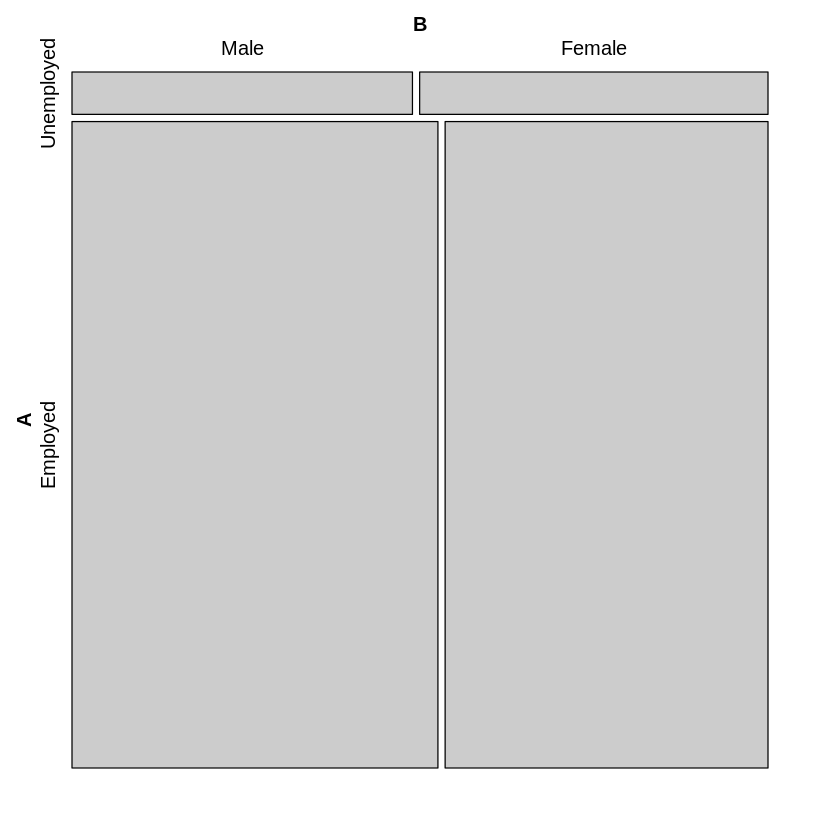

In [22]:
library(vcd)
mosaic(B)
ct <- chisq.test(B); print(ct)
print(ct$residuals)

結論：

- 根據卡方檢定，性別與失業狀況顯著相關 p-value < 0.05。
- 依據標準化殘差可知男性失業機率比期望次數低（為負值）；女性失業機率較期望次數高（為正值），故女性失業機率顯著高於男性。